In [1]:
import csv
import matplotlib.pyplot as plt
import os
import re
import shutil

shutil.rmtree('./results', ignore_errors=True)

In [2]:
def execute_sample_test(is_chain_test:bool, device:str, loop_step:int, max_val:int, n_trials:int, fixed_val:int, split:bool=False, printing:bool=False):
    """
    if is_chain_test is True, max_val represents the maximum number of chains,
    and fixed_val represents the fixed number of steps per chain.
    If is_chain_test is False, max_val represents the maximum number of steps per chain,
    and fixed_val represents the fixed number of chains.
    """
    if device not in ['cpu', 'cuda']:
        raise ValueError("Device must be 'cpu' or 'cuda'")
    if is_chain_test:
        cmd = f"python sampling_chain_dependance.py --device {device} --n-chains {max_val} --loop-step {loop_step} --n-trials {n_trials} --n-steps {fixed_val}"
    else:
        print("Executing step dependence test")
        cmd = f"python sampling_step_dependance.py --device {device} --n-steps {max_val} --loop-step {loop_step} --n-trials {n_trials} --n-chains {fixed_val}"
    if split:
        cmd += " --split"
    if printing:
        os.system(cmd)
    else:
        os.system(cmd + " > /dev/null 2>&1")

# Testing number of chains dependance

In [3]:
shutil.rmtree('./results', ignore_errors=True)
CHAIN_TEST = True
DEVICES = ['cpu', 'cuda']  # 'cpu' or 'cuda'
LOOP_STEP = 1000
MAX_CHAINS = 5000
N_TRIALS = 5
N_STEPS_PER_CHAIN = 1_000
for DEVICE in DEVICES:
    execute_sample_test(CHAIN_TEST, DEVICE, LOOP_STEP, MAX_CHAINS, N_TRIALS, N_STEPS_PER_CHAIN, split=False)
    execute_sample_test(CHAIN_TEST, DEVICE, LOOP_STEP, MAX_CHAINS, N_TRIALS, N_STEPS_PER_CHAIN, split=True)

Reading file: ./results/cuda/times_with_1000_split_True.csv
Reading file: ./results/cuda/times_with_1000_split_False.csv
Reading file: ./results/cpu/times_with_1000_split_True.csv
Reading file: ./results/cpu/times_with_1000_split_False.csv


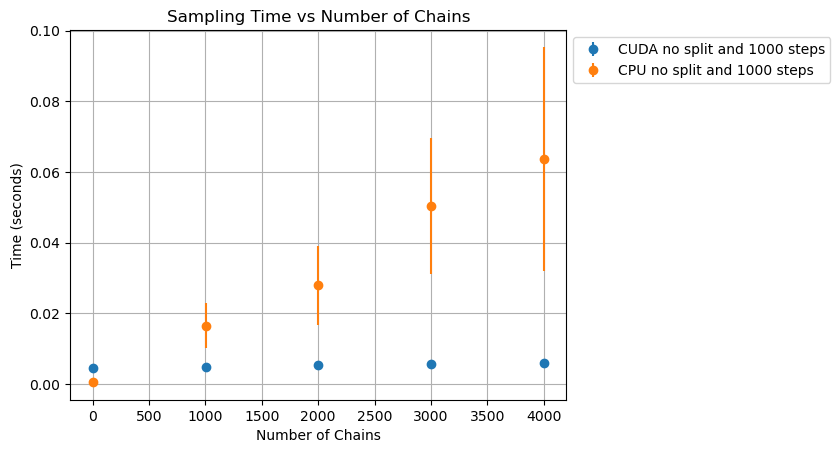

In [4]:
def extract_info_from_filename(filename):
    match = re.search(r"times_with_(\d+)_split_(True|False)", filename)
    if match:
        n_chains = int(match.group(1))
        split = match.group(2) == "True"
        return n_chains, split
    return None

def read_files(device):
    files = os.listdir(f"./results/{device}")
    times_split = {}
    for i,file in enumerate(files):
        times_split[i] = {"data": [], "metadata": {}}
        with open(f"./results/{device}/{file}", mode="r", newline="") as f:
            print(f"Reading file: {f.name}")
            reader = csv.reader(f)
            for row in reader:
                if row[0] != "Number of Chains":  # Skip header
                    times_split[i]["data"].append((int(row[0]), float(row[1]), float(row[2])))
                info = extract_info_from_filename(file)
                if info:
                    n_chains, split = info
                    times_split[i]["metadata"] = {"n_steps": n_chains, "split": split}
    return times_split

times_cuda = read_files("cuda")
times_cpu = read_files("cpu")

def plot_from_times_dict(times_dict, label_prefix):
    for key, value in times_dict.items():
        label = f"{label_prefix} {'with' if value['metadata']['split'] else 'no'} split and {value['metadata']['n_steps']} steps"
        if not value['metadata']['split'] and value['metadata']['n_steps'] == 1000:
            plt.errorbar(
                [x[0] for x in value['data']],
                [x[1] for x in value['data']],
                yerr=[x[2] for x in value['data']],
                fmt='o',
                label=label
            )

plot_from_times_dict(times_cuda, 'CUDA')
plot_from_times_dict(times_cpu, 'CPU')


plt.xlabel('Number of Chains')
plt.ylabel('Time (seconds)')
plt.title('Sampling Time vs Number of Chains')
plt.legend(
    loc='upper left',           # the corner of the legend box
    bbox_to_anchor=(1, 1),      # position of the legend outside the plot (x=1, y=1)
    borderaxespad=0.5           # optional padding
)
# plt.semilogy()
plt.grid(True)

# Testing number of steps per chain dependance

In [7]:
shutil.rmtree('./results/steps', ignore_errors=True)
CHAIN_TEST = False

STEPS_MAX = 10_000
N_TRIALS = 5
LOOP_STEP = 1000
N_STEPS = 1000
for DEVICE in DEVICES:
    execute_sample_test(CHAIN_TEST, DEVICE, LOOP_STEP, STEPS_MAX, N_TRIALS, N_STEPS, split=False)
    # execute_sample_test(CHAIN_TEST, DEVICE, LOOP_STEP, STEPS_MAX, N_TRIALS, N_STEPS, split=True)

Executing step dependence test
Executing step dependence test


Reading file: ./results/steps/cuda/times_with_1000_split_False.csv
Reading file: ./results/steps/cpu/times_with_1000_split_False.csv


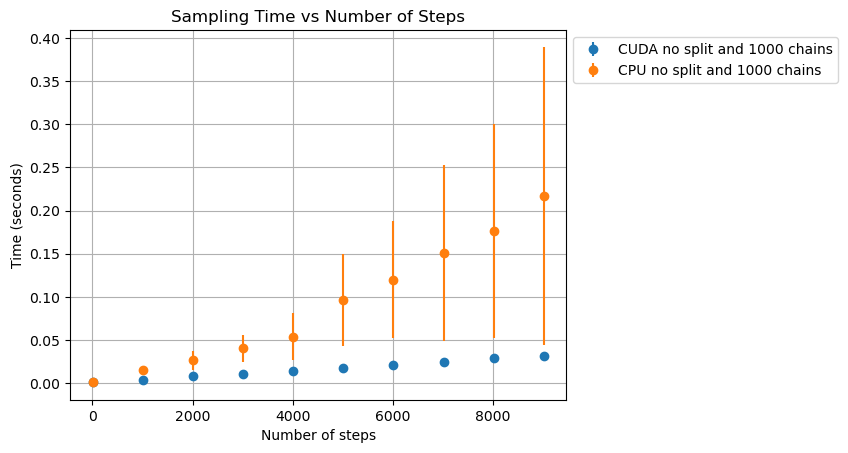

In [8]:
def read_files_steps(device):
    files = os.listdir(f"./results/steps/{device}")
    times_split = {}
    for i,file in enumerate(files):
        times_split[i] = {"data": [], "metadata": {}}
        with open(f"./results/steps/{device}/{file}", mode="r", newline="") as f:
            print(f"Reading file: {f.name}")
            reader = csv.reader(f)
            for row in reader:
                if row[0] != "Number of Steps":  # Skip header
                    times_split[i]["data"].append((int(row[0]), float(row[1]), float(row[2])))
                info = extract_info_from_filename(file)
                if info:
                    n_chains, split = info
                    times_split[i]["metadata"] = {"n_steps": n_chains, "split": split}
    return times_split

times_cuda_steps = read_files_steps("cuda")
times_cpu_steps = read_files_steps("cpu")
def plot_from_times_dict_steps(times_dict, label_prefix):
    for key, value in times_dict.items():
        label = f"{label_prefix} {'with' if value['metadata']['split'] else 'no'} split and {value['metadata']['n_steps']} chains"
        if not value['metadata']['split']:
            plt.errorbar(
                [x[0] for x in value['data']],
                [x[1] for x in value['data']],
                yerr=[x[2] for x in value['data']],
                fmt='o',
                label=label
            )

plot_from_times_dict_steps(times_cuda_steps, 'CUDA')
plot_from_times_dict_steps(times_cpu_steps, 'CPU')


plt.xlabel('Number of steps')
plt.ylabel('Time (seconds)')
plt.title('Sampling Time vs Number of Steps')
plt.legend(
    loc='upper left',           # the corner of the legend box
    bbox_to_anchor=(1, 1),      # position of the legend outside the plot (x=1, y=1)
    borderaxespad=0.5           # optional padding
)
# plt.semilogy()
plt.grid(True)

#### Looks like 500 chains is where CPU starts to get worse

In [8]:
shutil.rmtree('./results/steps', ignore_errors=True)
CHAIN_TEST = False

STEPS_MAX = 10_000
N_TRIALS = 5
LOOP_STEP = 1000
N_CHAINS = 500
for DEVICE in DEVICES:
    execute_sample_test(CHAIN_TEST, DEVICE, LOOP_STEP, STEPS_MAX, N_TRIALS, N_CHAINS, split=False)

Executing step dependence test
Executing step dependence test


Reading file: ./results/steps/cuda/times_with_500_split_False.csv
Reading file: ./results/steps/cpu/times_with_500_split_False.csv


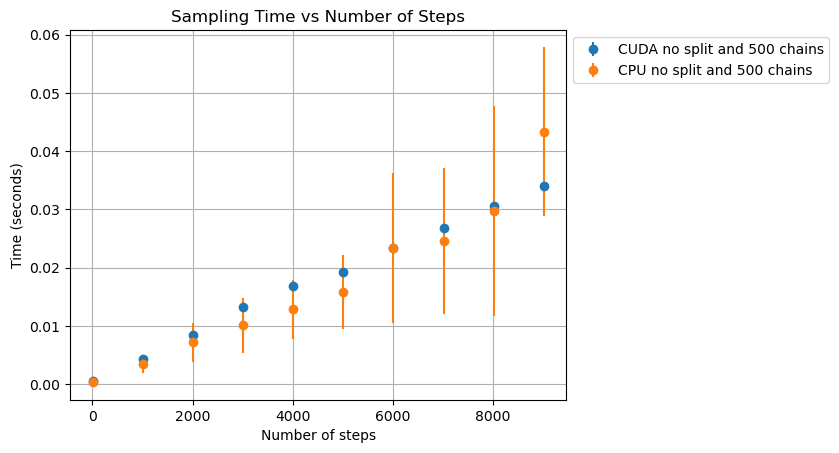

In [9]:
times_cuda_steps = read_files_steps("cuda")
times_cpu_steps = read_files_steps("cpu")

plot_from_times_dict_steps(times_cuda_steps, 'CUDA')
plot_from_times_dict_steps(times_cpu_steps, 'CPU')


plt.xlabel('Number of steps')
plt.ylabel('Time (seconds)')
plt.title('Sampling Time vs Number of Steps')
plt.legend(
    loc='upper left',           # the corner of the legend box
    bbox_to_anchor=(1, 1),      # position of the legend outside the plot (x=1, y=1)
    borderaxespad=0.5           # optional padding
)
# plt.semilogy()
plt.grid(True)

----------------

In [27]:
import jax
device = 'cuda'  # Change to 'cuda' to use GPU
N_CHAINS = 1_0
N_STEPS_PER_CHAIN = 10_0000
DoF = 120
hidden_units = 4096

jax.config.update("jax_platform_name", device)

print(jax.devices())

from jax import random
import jax.numpy as jnp
import time
from functools import partial


@partial(jax.jit, static_argnames=("prob_fn",))
def mh_chain_with_all_random_nums(random_values, prob_fn, init_pos):
    # Placeholder implementation of mh_chain

    def mh_kernel(carry, random_values):
        position, old_prob = carry
        proposal = position + (2 * random_values[0] - 1)
        proposal_prob = prob_fn(proposal)
        accept_prob = jnp.minimum(1.0, proposal_prob / old_prob)
        accept = random_values[-1] < accept_prob
        new_position = jnp.where(accept, proposal, position)
        new_prob = jnp.where(accept, proposal_prob, old_prob)
        carry = (new_position, new_prob)
        return carry, new_position

    initial_prob = prob_fn(init_pos)
    carry = (init_pos, initial_prob)
    positions, _ = jax.lax.scan(mh_kernel, carry, random_values)
    return positions


sampler = jax.vmap(mh_chain_with_all_random_nums, in_axes=(0, None, 0))


from flax import linen as nn
from jax import numpy as jnp


# Define a simple MLP using Flax Linen
class MLP(nn.Module):
    architecture: list
    hidden_activation: callable = nn.tanh
    alpha: float = 1.0  # parameter for the final wavefunction

    @nn.compact
    def __call__(self, x):
        for i in range(len(self.architecture) - 1):
            x = nn.Dense(features=self.architecture[i + 1])(x)
            if i < len(self.architecture) - 2:
                x = self.hidden_activation(x)

        return x
    
model = MLP(architecture=[DoF, hidden_units, 1], hidden_activation=nn.tanh, alpha=1.0)
params = model.init(random.PRNGKey(0), jnp.ones((1, DoF)))

@jax.jit
def prob_fn(x):
    psi = model.apply(params, x).squeeze()
    return jnp.square(psi)

[CudaDevice(id=0)]


In [28]:
def time_run_sampling(n_chains, n_steps, DoF=1, n_trials=10):

    start_time_prep = time.perf_counter()
    init_keys = jax.random.split(random.PRNGKey(42), n_chains)

    init_positions = jnp.zeros((n_chains, DoF))

    random_values = jax.random.uniform(random.PRNGKey(0), (n_chains, n_steps, DoF + 1))

    # Generate JAX array to append times of execution to have statistics
    execution_times = jnp.zeros(n_trials)
    end_time_prep = time.perf_counter()
    print(f"\tPreparation completed in {end_time_prep - start_time_prep:.2e} seconds.")

    start_time = time.perf_counter()
    _ = sampler(random_values, prob_fn, init_positions)
    end_time = time.perf_counter()
    print(f"\tWarm-up sampling completed in {end_time - start_time:.2e} seconds.")

    for i in range(n_trials):
        start_time = time.perf_counter()
        result = sampler(random_values, prob_fn, init_positions)
        jax.tree.map(lambda x: x.block_until_ready(), result)

        end_time = time.perf_counter()
        print(f"\t\tSampling completed in {end_time - start_time:.2e} seconds.")

        start_time_append = time.perf_counter()
        execution_times = execution_times.at[i].set(end_time - start_time)
        end_time_append = time.perf_counter()
        print(
            f"\tTiming recorded in {end_time_append - start_time_append:.2e} seconds."
        )

    print(f"\tAll {n_trials} trials completed.")
    start_mean_std = time.perf_counter()
    mean_time = execution_times.mean().item()
    std_time = execution_times.std().item()
    end_mean_std = time.perf_counter()
    print(f"\tMean and std computed in {end_mean_std - start_mean_std:.2e} seconds.")

    return mean_time, std_time


In [29]:
start = time.perf_counter()
if device == 'cuda':
    mean_time, std_time = time_run_sampling( n_chains = N_CHAINS, n_steps = N_STEPS_PER_CHAIN, n_trials=2, DoF=DoF)
elif device == 'cpu':
    mean_time, std_time = time_run_sampling( n_chains = 1, n_steps = N_CHAINS*N_STEPS_PER_CHAIN, n_trials=2, DoF=DoF)
end = time.perf_counter()
print(f"Total time taken: {end - start:.2e} seconds")

	Preparation completed in 2.86e-01 seconds.


2025-12-17 13:22:00.159637: W external/xla/xla/tsl/framework/bfc_allocator.cc:501] Allocator (GPU_0_bfc) ran out of memory trying to allocate 463.62MiB (rounded to 486141184)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
2025-12-17 13:22:00.159721: W external/xla/xla/tsl/framework/bfc_allocator.cc:512] ********************************************************************************************________
E1217 13:22:00.159736   25684 pjrt_stream_executor_client.cc:2939] Execution of replica 0 failed: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 486140960 bytes. [tf-allocator-allocation-error='']


XlaRuntimeError: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 486140960 bytes.

In [ ]:
print(f"Mean time: {mean_time}, Std time: {std_time}")

Mean time: 3.3294074535369873, Std time: 0.0163881778717041
